### Establecer semilla


In [13]:
import torch
import random
import numpy as np
import os

SEED = 112

def set_seed(seed=17):
    # 1. Fija la semilla para el módulo random base de Python
    random.seed(seed)
    
    # 2. Fija la semilla en las variables de entorno (afecta al hash de Python)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. Fija la semilla para NumPy (muy importante si usas Pandas o Scikit-learn)
    np.random.seed(seed)
    
    # 4. Fija la semilla para PyTorch (CPU)
    torch.manual_seed(seed)
    
    # 5. Fija la semilla para PyTorch (GPU / CUDA)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    # 6. Fuerza a CuDNN a usar algoritmos deterministas (solo si usas GPU)
    # Se prioriza la reproducibilidad determinista durante la fase experimental mediante la restricción de heurísticas de cuDNN,
    # asumiendo una ligera penalización en el rendimiento computacional a favor del rigor evaluativo.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Ejecuta la función al inicio
set_seed(SEED)

### Carga de archivos .parquet y análisis de distribución de servicios


Se han encontrado 7 archivos Parquet.
¡Hecho! Dataset total con 1,916,757 registros cargados.

--- CLASES DETECTADAS (8) ---
Clase 0: Benigno -> 958,109 registros
Clase 1: Credential Access -> 871,188 registros
Clase 2: Defense Evasion -> 6,048 registros
Clase 3: Exfiltration -> 559 registros
Clase 4: Initial Access -> 10,662 registros
Clase 5: Persistence -> 6,048 registros
Clase 6: Privilege Escalation -> 6,048 registros
Clase 7: Reconnaissance -> 58,095 registros

--- DISTRIBUCIÓN GLOBAL ---
             Cantidad  Porcentaje (%)
service                              
dns            879490           45.88
ssl            860606           44.90
desconocido    154477            8.06
http             9847            0.51
ntp              6628            0.35


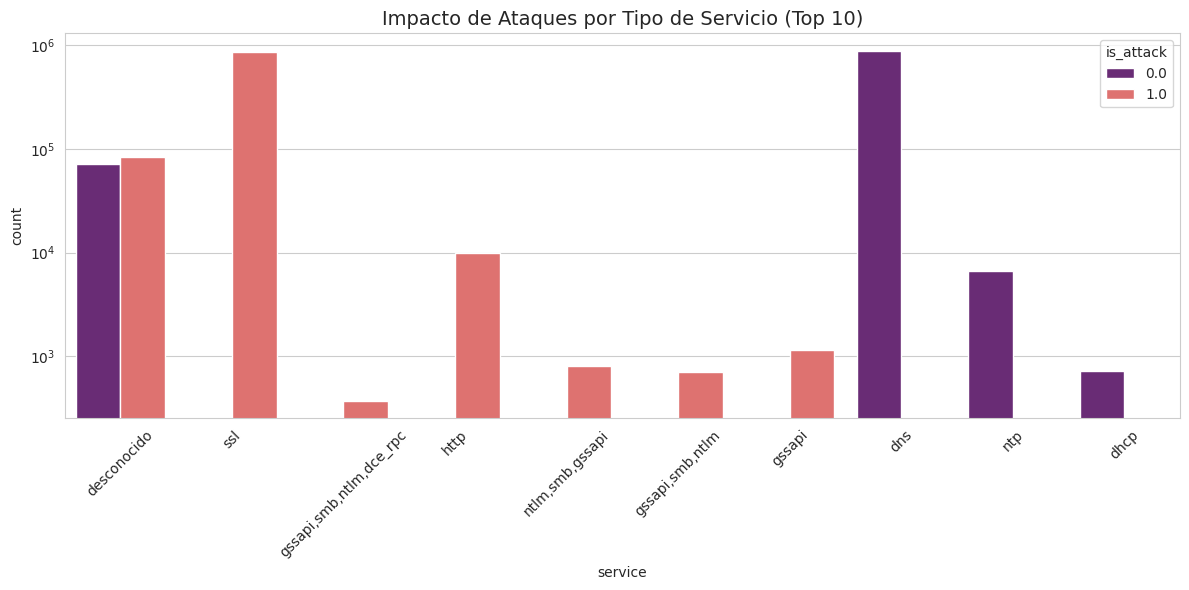

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. LOCALIZACIÓN Y CARGA
archivos_parquet = glob.glob("../data/raw/*.parquet")
print(f"Se han encontrado {len(archivos_parquet)} archivos Parquet.")

lista_df = []
for f in archivos_parquet:
    # Añadimos las columnas numéricas que Zeek nos da para las Edge Features
    columnas_interes = ['service', 'label_tactic', 'src_ip_zeek', 'dest_ip_zeek', 
                        'duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts', 'conn_state', 'missed_bytes', 'ts']
    temp_df = pd.read_parquet(f, columns=columnas_interes)
    lista_df.append(temp_df)

df = pd.concat(lista_df, ignore_index=True)
print(f"¡Hecho! Dataset total con {len(df):,} registros cargados.")

# 2. LIMPIEZA Y CODIFICACIÓN DE ETIQUETAS MULTICLASE
df['service'] = df['service'].replace(['-', ''], 'desconocido').fillna('desconocido')
df['is_attack'] = (df['label_tactic'].fillna('none').str.lower() != 'none').astype(float)

# Limpiamos los nulos y asignamos 'Benigno' a lo que no es ataque
df['label_tactic'] = df['label_tactic'].fillna('Benigno').replace(['none', '-'], 'Benigno')

# Codificamos las tácticas a números (0, 1, 2...)
encoder_tactics = LabelEncoder()
df['target_class'] = encoder_tactics.fit_transform(df['label_tactic'])

num_clases = len(encoder_tactics.classes_)
print(f"\n--- CLASES DETECTADAS ({num_clases}) ---")
for i, clase in enumerate(encoder_tactics.classes_):
    print(f"Clase {i}: {clase} -> {len(df[df['target_class'] == i]):,} registros")

# 3. DIAGNÓSTICO
resumen = pd.DataFrame({
    'Cantidad': df['service'].value_counts(),
    'Porcentaje (%)': (df['service'].value_counts(normalize=True) * 100).round(2)
})
print("\n--- DISTRIBUCIÓN GLOBAL ---")
print(resumen.head())

# 4. VISUALIZACIÓN
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
top_10 = df['service'].value_counts().head(10).index
df_plot = df[df['service'].isin(top_10)]

sns.countplot(data=df_plot, x='service', hue='is_attack', palette='magma')
plt.title('Impacto de Ataques por Tipo de Servicio (Top 10)', fontsize=14)
plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Enrutador y Partición Estratificada Train/Test


In [15]:
from sklearn.model_selection import train_test_split
import numpy as np
import torch

df = df.sort_values(by=['src_ip_zeek', 'dest_ip_zeek', 'ts']).reset_index(drop=True)

print("Generando divisiones estratificadas: Train (70%), Val (10%), Test (20%)...")

# 1. Estratificación
df['stratify_key'] = df['service'] + '_' + df['is_attack'].astype(int).astype(str)
conteo_clases = df['stratify_key'].value_counts()
clases_validas = conteo_clases[conteo_clases > 1].index

indices_validos = df.index[df['stratify_key'].isin(clases_validas)].tolist()

# --- DOBLE DIVISIÓN (Train/Val/Test) ---
# Primera división: separamos el 20% para Test
idx_train_val, idx_test = train_test_split(
    indices_validos, 
    test_size=0.20, 
    random_state=42, 
    stratify=df.loc[indices_validos, 'stratify_key']
)

# Segunda división: del 80% restante, sacamos un 12.5% (que equivale exactamente al 10% del total global) para Val
y_train_val = df.loc[idx_train_val, 'stratify_key']
conteo_clases = y_train_val.value_counts()
clases_raras = conteo_clases[conteo_clases < 2].index

mascara_raras = y_train_val.isin(clases_raras)
idx_raros = np.array(idx_train_val)[mascara_raras]
idx_normales = np.array(idx_train_val)[~mascara_raras]
y_normales = y_train_val[~mascara_raras]

if len(clases_raras) > 0:
    print(f"⚠️ Clases críticas detectadas (< 2 muestras): {clases_raras.tolist()}")
    print("Forzando su inclusión en el set de Entrenamiento...")

idx_train_normal, idx_val = train_test_split(
    idx_normales, 
    test_size=0.125, # Equivale al 10% del total global
    random_state=42, 
    stratify=y_normales
)

idx_train = np.concatenate([idx_train_normal, idx_raros])
np.random.shuffle(idx_train)

# Inicializamos las máscaras maestras
train_mask = torch.zeros(len(df), dtype=torch.bool)
val_mask = torch.zeros(len(df), dtype=torch.bool)
test_mask = torch.zeros(len(df), dtype=torch.bool)

train_mask[idx_train] = True
val_mask[idx_val] = True
test_mask[idx_test] = True

# 2. DEFINIMOS LOS GRUPOS LÓGICOS DE SERVICIOS
servicios = df['service'].values
is_ataque = df['is_attack'].values
is_ataque_tensor = torch.tensor(is_ataque == 1, dtype=torch.bool)

mask_web = np.isin(servicios, ['ssl', 'http'])
mask_infra = np.isin(servicios, ['dns', 'ntp', 'dhcp'])
mask_auth = np.isin(servicios, ['smb', 'gssapi', 'ntlm', 'dce_rpc', 'gssapi,smb,ntlm', 'smb,dce_rpc,ntlm,gssapi', 'ntlm,dce_rpc,smb,gssapi']) 
mask_gen = ~(mask_web | mask_infra | mask_auth) 

# --- INYECCIÓN DE VARIANZA (SOLO PARA TRAIN) ---
benignos_disponibles = mask_gen & (is_ataque == 0)
ataques_disponibles = mask_gen & (is_ataque == 1)

mask_train_web = (mask_web | benignos_disponibles)
mask_train_infra = (mask_infra | ataques_disponibles)
mask_train_auth = (mask_auth | benignos_disponibles) 

# ========================================================
# MÁSCARAS FASE 1: BINARIAS (Portero)
# ========================================================
# TRAIN (Con Inyección)
train_mask_web = torch.tensor(mask_train_web, dtype=torch.bool) & train_mask
train_mask_infra = torch.tensor(mask_train_infra, dtype=torch.bool) & train_mask
train_mask_auth = torch.tensor(mask_train_auth, dtype=torch.bool) & train_mask
train_mask_gen = torch.tensor(mask_gen, dtype=torch.bool) & train_mask

# VALIDACIÓN (Estrictas, reflejan la realidad para el Early Stopping)
val_mask_web = torch.tensor(mask_web, dtype=torch.bool) & val_mask
val_mask_infra = torch.tensor(mask_infra, dtype=torch.bool) & val_mask
val_mask_auth = torch.tensor(mask_auth, dtype=torch.bool) & val_mask
val_mask_gen = torch.tensor(mask_gen, dtype=torch.bool) & val_mask

# TEST (Estrictas)
test_mask_web = torch.tensor(mask_web, dtype=torch.bool) & test_mask
test_mask_infra = torch.tensor(mask_infra, dtype=torch.bool) & test_mask
test_mask_auth = torch.tensor(mask_auth, dtype=torch.bool) & test_mask
test_mask_gen = torch.tensor(mask_gen, dtype=torch.bool) & test_mask

# ========================================================
# MÁSCARAS FASE 2: MULTICLASE (Analista Forense)
# ========================================================
# TRAIN (Con Inyección de ataques cruzados)
ataques_inyeccion = torch.tensor(
    ataques_disponibles,
    dtype=torch.bool
) & train_mask

train_mask_web_ataques = (
    train_mask_web &
    is_ataque_tensor
) | ataques_inyeccion

train_mask_infra_ataques = (
    train_mask_infra &
    is_ataque_tensor
) | ataques_inyeccion

train_mask_auth_ataques = (
    train_mask_auth &
    is_ataque_tensor
) | ataques_inyeccion

train_mask_gen_ataques = (
    train_mask_gen &
    is_ataque_tensor
)

# VALIDACIÓN (Solo evalúan sobre ataques reales y naturales del set de Val)
val_mask_web_ataques = val_mask_web & is_ataque_tensor
val_mask_infra_ataques = val_mask_infra & is_ataque_tensor
val_mask_auth_ataques = val_mask_auth & is_ataque_tensor
val_mask_gen_ataques = val_mask_gen & is_ataque_tensor


# --- UNDERSAMPLING SELECTIVO Y BLINDADO ---
# 1. Definimos qué clases son sagradas y NO deben tocarse nunca
clases_sagradas = ['Exfiltration', 'Persistence', 'Defense Evasion', 'Privilege Escalation', 'Initial Access']
ids_sagrados = encoder_tactics.transform(clases_sagradas)

# 2. Identificamos los índices que son candidatos a ser borrados:
# Solo borraremos si es 'Benigno' o 'Credential Access' (id 0 e id 1 normalmente)
# Y SOLO si están en el conjunto de entrenamiento
idx_train_np = np.where(train_mask.numpy())[0]
y_train_cpu = df.loc[idx_train_np, 'target_class'].values

# Buscamos quiénes NO son sagrados dentro del entrenamiento
idx_candidatos_borrado = []
for i, etiqueta in zip(idx_train_np, y_train_cpu):
    if etiqueta not in ids_sagrados:
        idx_candidatos_borrado.append(i)

# 3. Aplicamos el recorte solo a los candidatos (75% de descarte)
num_descarte = int(len(idx_candidatos_borrado) * 0.75)
np.random.seed(SEED)
idx_a_apagar = np.random.choice(idx_candidatos_borrado, num_descarte, replace=False)

# 4. Actualizamos la máscara de entrenamiento final
# Creamos una copia de la máscara original y apagamos los elegidos
mascara_apagado = torch.zeros(len(df), dtype=torch.bool)
mascara_apagado[idx_a_apagar] = True

# Actualizamos la máscara maestra para que el Feature Engineering
# no use las filas que acabamos de descartar.
train_mask = train_mask & ~mascara_apagado

train_mask_web = train_mask_web & ~mascara_apagado
train_mask_infra = train_mask_infra & ~mascara_apagado
train_mask_auth = train_mask_auth & ~mascara_apagado
train_mask_gen = train_mask_gen & ~mascara_apagado

# Inyectamos los tensores como columnas booleanas en el DataFrame
# para evitar el KeyError en la siguiente celda.
df['train_mask'] = train_mask.numpy()
df['val_mask'] = val_mask.numpy()
df['test_mask'] = test_mask.numpy()

print(f"Undersampling completado. Se han protegido las clases: {clases_sagradas}")

Generando divisiones estratificadas: Train (70%), Val (10%), Test (20%)...
Undersampling completado. Se han protegido las clases: ['Exfiltration', 'Persistence', 'Defense Evasion', 'Privilege Escalation', 'Initial Access']


### Feature Engineering (Nodos Inductivos y Aristas)

Para que el modelo sea verdaderamente inductivo y agnóstico a la IP, las características iniciales de los nodos (X) deben ser estadísticas de comportamiento.


In [16]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

print("1. Procesando Características de las Aristas (Edge Features Avanzadas)...")

# --- INGENIERÍA DE CARACTERÍSTICAS TEMPORALES Y GLOBALES ---
print("Calculando delta temporal para detectar Persistencia (Beaconing)...")
# Esto se hace sobre TODO el df para no perder la secuencia temporal en test/val. 

# Esta característica se calcula utilizando únicamente
# eventos anteriores dentro de cada flujo ordenado
# temporalmente.
#
# Dependiendo de cómo se realice la partición train/test,
# puede existir dependencia entre la última conexión de
# train y la primera de test.
#
# No supone leakage en inferencia online, pero debe
# tenerse en cuenta al evaluar experimentalmente.
df['time_since_last_conn'] = df.groupby(['src_ip_zeek', 'dest_ip_zeek'])['ts'].diff().fillna(0.0)

# 1. Añadimos variable temporal y missed_bytes (Sobre el df completo)
edge_cols = ['duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts', 'missed_bytes', 'time_since_last_conn']
df[edge_cols] = df[edge_cols].fillna(0)

# 2. One-Hot Encoding del estado de la conexión
df['conn_state'] = df['conn_state'].fillna('OTH')
# Se hace en todo el df para que no falten columnas si un estado raro solo aparece en test
conn_state_dummies = pd.get_dummies(df['conn_state'], prefix='state').astype(float)

# 3. Concatenamos numéricas y categóricas para tener la matriz TOTAL
edge_features_df = pd.concat([df[edge_cols], conn_state_dummies], axis=1)

# 4. Estandarizamos (AQUÍ EVITAMOS EL LEAKAGE)
scaler_edges = StandardScaler()
# FIT: Solo aprende la media y varianza de las filas de TRAIN
scaler_edges.fit(edge_features_df[df['train_mask']].values)
# TRANSFORM: Lo aplicamos a TODO el dataset para no quedarnos cortos de filas para el grafo
edge_features_np = scaler_edges.transform(edge_features_df.values)

print(f"-> Aristas procesadas. Nuevas dimensiones de Edge Features: {edge_features_np.shape} (Total de conexiones)")


print("\n2. Procesando Características de los Nodos (Node Features Inductivas)...")

# Aislamos el train SOLO para calcular las estadísticas históricas
df_train = df[df['train_mask']]

# USO DE NAMED AGGREGATION (Soluciona el error de las columnas)
# Calculamos estadísticas cuando la IP actúa como ORIGEN (Out) - SOLO TRAIN
out_stats = df_train.groupby('src_ip_zeek').agg(
    out_bytes_mean=('orig_bytes', 'mean'),
    out_pkts_mean=('orig_pkts', 'mean'),
    out_degree=('orig_bytes', 'count') # El conteo de conexiones
)

# Calculamos estadísticas cuando la IP actúa como DESTINO (In) - SOLO TRAIN
in_stats = df_train.groupby('dest_ip_zeek').agg(
    in_bytes_mean=('resp_bytes', 'mean'),
    in_pkts_mean=('resp_pkts', 'mean'),
    in_degree=('resp_bytes', 'count')
)

# Sacamos TODAS las IPs únicas del df completo para no dejar al Test sin nodos
ips_unicas = pd.unique(df[['src_ip_zeek', 'dest_ip_zeek']].values.ravel('K'))

node_df = pd.DataFrame(index=ips_unicas)
node_df = node_df.join(out_stats).join(in_stats).fillna(0)

# ESCALADO DE NODOS SIN LEAKAGE
# Averiguamos qué IPs operaron en el train para ajustar el scaler solo con ellas
ips_train = pd.unique(df_train[['src_ip_zeek', 'dest_ip_zeek']].values.ravel('K'))

scaler_nodes = StandardScaler()
# FIT: Solo con las IPs del Train
scaler_nodes.fit(node_df.loc[ips_train].values)
# TRANSFORM: A todas las IPs del grafo
node_features_np = scaler_nodes.transform(node_df.values)

print(f"-> Nodos procesados con éxito: {len(ips_unicas):,}")

1. Procesando Características de las Aristas (Edge Features Avanzadas)...
Calculando delta temporal para detectar Persistencia (Beaconing)...
-> Aristas procesadas. Nuevas dimensiones de Edge Features: (1916757, 14) (Total de conexiones)

2. Procesando Características de los Nodos (Node Features Inductivas)...
-> Nodos procesados con éxito: 357


### Construcción del Grafo en PyTorch


In [17]:
import torch

print("Construyendo matriz de adyacencia...")
# Codificamos las IPs a índices numéricos (0 a N)
mapeo_ips = {ip: i for i, ip in enumerate(node_df.index)}
df['src_id'] = df['src_ip_zeek'].map(mapeo_ips)
df['dst_id'] = df['dest_ip_zeek'].map(mapeo_ips)

# 1. Matriz de Adyacencia Global (edge_index) [2, num_aristas]
origen = torch.tensor(df['src_id'].values, dtype=torch.long)
destino = torch.tensor(df['dst_id'].values, dtype=torch.long)
edge_index_total = torch.stack([origen, destino], dim=0)

# 2. Tensores de Características (X) y Aristas (Edge_Attr)
x_nodos = torch.tensor(node_features_np, dtype=torch.float)
edge_attr_total = torch.tensor(edge_features_np, dtype=torch.float)

# 3. Etiquetas (Target multiclase)
# IMPORTANTE: CrossEntropyLoss requiere que las etiquetas sean 'long' (enteros)
y_total = torch.tensor(df['target_class'].values, dtype=torch.long)
edge_services = df['service'].values

print(f"Tensor X (Nodos): {x_nodos.shape}")
print(f"Tensor edge_index (Topología): {edge_index_total.shape}")

Construyendo matriz de adyacencia...
Tensor X (Nodos): torch.Size([357, 6])
Tensor edge_index (Topología): torch.Size([2, 1916757])


### Exportación de datos


In [18]:
import os
import json

print("\n--- Exportando Datasets de Simulación e Histórico ---")
os.makedirs("../data/processed", exist_ok=True)

# 1. El Dataset de Simulación (SOLO TEST)
df_test_estricto = df.iloc[idx_test].copy()
df_test_estricto = df_test_estricto.sort_values(by='ts')
df_test_estricto.to_parquet("../data/processed/dataset_simulacion_kafka.parquet", index=False)

# 2. El Dataset Histórico para Neo4j (TRAIN + VAL)
df_historico = df[~df.index.isin(idx_test)].copy()
df_historico = df_historico.sort_values(by='ts')
df_historico.to_parquet("../data/processed/dataset_historico_neo4j.parquet", index=False)

# 3. Exportar el orden de las columnas (esto no cambia)
columnas_modelo = list(edge_features_df.columns)
with open("../data/processed/columnas_modelo.json", "w") as f:
    json.dump(columnas_modelo, f)

print(f"✅ Simulación (Test) exportada: {len(df_test_estricto):,} registros.")
print(f"✅ Histórico (Train+Val) exportado: {len(df_historico):,} registros.")


--- Exportando Datasets de Simulación e Histórico ---
✅ Simulación (Test) exportada: 383,352 registros.
✅ Histórico (Train+Val) exportado: 1,533,405 registros.


### Arquitectura GraphSAGE (El Modelo)


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, GATConv
from detector_mitre import AdvancedEdgeExpert

# Mejoras integradas para robustez y generalización

Cambios aplicados directamente al pipeline:

- Gamma dinámico para Focal Loss
- Oversampling basado en percentiles
- Corrección automática de device CUDA/CPU
- Early stopping usando Macro-F1
- Eliminación de parada por "perfección"
- Mitigación de leakage topológico
- Normalización más estable de pesos de clases

Las funciones auxiliares se definen justo antes de utilizarse
para mantener el notebook legible y autocontenido.


### Bucle de Entrenamiento

Durante el entrenamiento se utiliza la topología completa,
lo que introduce una componente transductiva.

Durante la evaluación se restringe el message passing
a las aristas históricas (Train+Val), reduciendo la
filtración estructural hacia el conjunto Test.


In [20]:
import numpy as np
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Entrenando en: {device}\n")

# --- 1. ETIQUETAS Y MÁSCARAS DE DOS FASES ---
y_binario = torch.tensor(df['is_attack'].astype(int).values, dtype=torch.long).to(device)
is_ataque_tensor = torch.tensor(df['is_attack'].values == 1, dtype=torch.bool)

ataques_inyeccion = torch.tensor(ataques_disponibles, dtype=torch.bool) & train_mask

train_mask_web_ataques = (torch.tensor(mask_web, dtype=torch.bool) & train_mask & is_ataque_tensor) | ataques_inyeccion
train_mask_infra_ataques = (torch.tensor(mask_infra, dtype=torch.bool) & train_mask & is_ataque_tensor) | ataques_inyeccion
train_mask_auth_ataques = (torch.tensor(mask_auth, dtype=torch.bool) & train_mask & is_ataque_tensor) | ataques_inyeccion
train_mask_gen_ataques = torch.tensor(mask_gen, dtype=torch.bool) & train_mask & is_ataque_tensor

# --- 2. COMITÉ FASE 1: BINARIO (El Filtro Portero) ---
model_bin_web = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, 2, 'SAGE', 0.3).to(device)
model_bin_infra = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 64, 2, 'SAGE', 0.2).to(device)
model_bin_auth = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, 2, 'GAT', 0.4).to(device)
model_bin_gen = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 256, 2, 'GAT', 0.5).to(device)

opt_bin_web = torch.optim.Adam(model_bin_web.parameters(), lr=0.005)
opt_bin_infra = torch.optim.Adam(model_bin_infra.parameters(), lr=0.005)
opt_bin_auth = torch.optim.Adam(model_bin_auth.parameters(), lr=0.003)
opt_bin_gen = torch.optim.Adam(model_bin_gen.parameters(), lr=0.001)

# --- 3. COMITÉ FASE 2: MULTICLASE (El Analista Forense - Soft Voting Ensemble) ---
model_multi_web = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, num_clases, 'SAGE', 0.3).to(device)
opt_multi_web = torch.optim.Adam(model_multi_web.parameters(), lr=0.005)

model_multi_infra_sage = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 64, num_clases, 'SAGE', 0.2).to(device)
model_multi_infra_gat = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 64, num_clases, 'GAT', 0.2).to(device)
opt_multi_infra_sage = torch.optim.Adam(model_multi_infra_sage.parameters(), lr=0.005)
opt_multi_infra_gat = torch.optim.Adam(model_multi_infra_gat.parameters(), lr=0.001)

model_multi_auth_sage = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, num_clases, 'SAGE', 0.4).to(device)
model_multi_auth_gat = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, num_clases, 'GAT', 0.4).to(device)
opt_multi_auth_sage = torch.optim.Adam(model_multi_auth_sage.parameters(), lr=0.003)
opt_multi_auth_gat = torch.optim.Adam(model_multi_auth_gat.parameters(), lr=0.001)

model_multi_gen_sage = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 256, num_clases, 'SAGE', 0.5).to(device)
model_multi_gen_gat = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 256, num_clases, 'GAT', 0.5).to(device)
opt_multi_gen_sage = torch.optim.Adam(model_multi_gen_sage.parameters(), lr=0.001)
opt_multi_gen_gat = torch.optim.Adam(model_multi_gen_gat.parameters(), lr=0.001)

x_nodos = x_nodos.to(device)
edge_index_total = edge_index_total.to(device)

def gestionar_mascaras_y_fallback(mascara_train, mascara_val):
    idx_train = torch.where(mascara_train)[0].cpu()
    idx_val = torch.where(mascara_val)[0].cpu()
    if len(idx_val) == 0 and len(idx_train) > 0:
        print("⚠️ Validación vacía. Aplicando split 80/20 interno de seguridad.")
        perm = torch.randperm(len(idx_train))
        split = int(len(idx_train) * 0.8)
        idx_val = idx_train[perm[split:]]
        idx_train = idx_train[perm[:split]]
    return idx_train, idx_val

def aplicar_augmentacion_topologica(idx_train_base, y_multiclase_global, num_clases):
    # AHORA LA AUGMENTACIÓN MIRA LA ETIQUETA GLOBAL PARA IDENTIFICAR A LOS RAROS, INCLUSO EN FASE 1
    y_train_np = y_multiclase_global[idx_train_base].cpu().numpy()
    counts = np.bincount(y_train_np, minlength=num_clases)
    
    target_muestras = 15000 
    indices_extra = []
    
    for c in np.unique(y_train_np):
        # No clonamos la clase 0 (Benigno), solo los ataques que están bajo el umbral
        if c != 0 and 0 < counts[c] < target_muestras:
            factor = int(target_muestras / counts[c])
            if factor > 1:
                indices_clase = idx_train_base[y_train_np == c]
                indices_extra.extend(np.tile(indices_clase.numpy(), factor - 1))
    
    if indices_extra:
        print(f"[*] Augmentación: +{len(indices_extra)} aristas inyectadas para clases minoritarias.")
        return torch.cat([idx_train_base, torch.tensor(indices_extra, dtype=torch.long)])
        
    return idx_train_base

def calcular_focal_loss_dinamica(y_train_base, is_multiclass, num_clases, device):
    conteo = np.bincount(y_train_base.cpu().numpy(), minlength=num_clases if is_multiclass else 2)
    pesos = torch.ones(len(conteo), device=device)
    gammas = torch.full((len(conteo),), 2.0, device=device) 

    for c in range(len(conteo)):
        if conteo[c] > 0:
            pesos[c] = 1.0 / (conteo[c] ** 0.5) 
            if is_multiclass:
                ratio = np.max(conteo[conteo > 0]) / conteo[c]
                gammas[c] = min(3.0, 1.0 + np.log10(ratio)) 

    clases_presentes = len(np.unique(y_train_base.cpu().numpy()))
    pesos = (pesos / pesos.sum()) * clases_presentes
    return FocalLoss(weight=pesos, gamma=gammas.mean().item())

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.weight is not None:
            focal_loss = focal_loss * self.weight[targets]
        return focal_loss.mean()

def entrenar_experto_gnn(nombre, modelo, optimizador, mascara_train, mascara_val, y_target, grafo_global, is_multiclass=False, epochs=1000, paciencia=50):
    print(f"\n--- Entrenando Experto: {nombre} ---")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    modelo.to(device)

    x_nodos = grafo_global['x_nodos'].to(device)
    edge_index_t = grafo_global['edge_index_total']
    edge_attr_t = grafo_global['edge_attr_total']
    num_clases = grafo_global['num_clases']
    y_total_global = grafo_global['y_total'].to(device) # Etiqueta original multiclase

    idx_train_base, idx_val = gestionar_mascaras_y_fallback(mascara_train, mascara_val)
    if len(idx_train_base) == 0: return

    y_train_base = y_target[idx_train_base.to(y_target.device)].to(device)
    criterion = calcular_focal_loss_dinamica(y_train_base, is_multiclass, num_clases, device)

    # APLICAMOS LA AUGMENTACIÓN SIEMPRE USANDO LA ETIQUETA GLOBAL
    idx_train_pred = aplicar_augmentacion_topologica(idx_train_base, y_total_global, num_clases)

    # Grafo de mensajes (Topología real, SIN duplicados)
    edge_idx_msg_train = edge_index_t[:, idx_train_base.to(edge_index_t.device)].to(device)
    
    # Grafo de predicción (Aristas a predecir, CON duplicados para Loss)
    edge_idx_pred_train = edge_index_t[:, idx_train_pred.to(edge_index_t.device)].to(device)
    edge_attr_pred_train = edge_attr_t[idx_train_pred.to(edge_attr_t.device)].to(device)
    y_train_pred = y_target[idx_train_pred.to(y_target.device)].to(device)
    
    # Tensores de Validación
    idx_val_device = idx_val.to(edge_index_t.device)
    edge_idx_pred_val = edge_index_t[:, idx_val_device].to(device)
    edge_idx_msg_val = torch.cat([edge_idx_msg_train, edge_idx_pred_val], dim=1) # Train + Val reales
    
    edge_attr_pred_val = edge_attr_t[idx_val.to(edge_attr_t.device)].to(device)
    y_val_pred = y_target[idx_val.to(y_target.device)].to(device)

    mejor_f1_val = -1.0 
    mejor_modelo_pesos = None
    paciencia_cnt = 0

    for epoch in range(epochs):
        modelo.train()
        optimizador.zero_grad()
        
        out = modelo(x_nodos, edge_idx_msg_train, edge_idx_pred_train, edge_attr_pred_train)
        
        loss = criterion(out, y_train_pred)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
        optimizador.step()

        modelo.eval()
        with torch.no_grad():
            out_v = modelo(x_nodos, edge_idx_msg_val, edge_idx_pred_val, edge_attr_pred_val)
            preds_v = out_v.argmax(dim=1)
            f1_v = f1_score(y_val_pred.cpu(), preds_v.cpu(), average='macro', zero_division=0)

        if f1_v > mejor_f1_val:
            mejor_f1_val = f1_v
            mejor_modelo_pesos = copy.deepcopy(modelo.state_dict())
            paciencia_cnt = 0
        else:
            paciencia_cnt += 1

        if (epoch+1) % 50 == 0:
            print(f"Ep {epoch+1:03d} | Train Loss: {loss.item():.4f} | Val Macro-F1: {f1_v:.4f}")

        if paciencia_cnt >= paciencia:
            print(f"🛑 Early Stopping en ep {epoch+1}. Mejor Macro-F1: {mejor_f1_val:.4f}")
            break

    if mejor_modelo_pesos is not None:
        modelo.load_state_dict(mejor_modelo_pesos)
    print(f"✅ Experto {nombre} listo.")
    
# ================= ENTRENAMIENTO EN MASA =================
grafo_global = {
    'x_nodos': x_nodos,
    'edge_index_total': edge_index_total,
    'edge_attr_total': edge_attr_total,
    'num_clases': num_clases,
    'y_total': y_total # ¡PASAMOS EL TARGET MULTICLASE GLOBAL AQUI!
}

print(">>> INICIANDO FASE 1 (MODELOS BINARIOS - FILTRADO)")
entrenar_experto_gnn("BIN. WEB", model_bin_web, opt_bin_web, train_mask_web, val_mask_web, y_binario, grafo_global, is_multiclass=False, epochs=150)
entrenar_experto_gnn("BIN. INFRA", model_bin_infra, opt_bin_infra, train_mask_infra, val_mask_infra, y_binario, grafo_global, is_multiclass=False, epochs=150)
entrenar_experto_gnn("BIN. AUTH", model_bin_auth, opt_bin_auth, train_mask_auth, val_mask_auth, y_binario, grafo_global, is_multiclass=False, epochs=200)
entrenar_experto_gnn("BIN. GEN", model_bin_gen, opt_bin_gen, train_mask_gen, val_mask_gen, y_binario, grafo_global, is_multiclass=False, epochs=250)

print("\n>>> INICIANDO FASE 2 (MODELOS MULTICLASE - CLASIFICACIÓN MITRE)")
entrenar_experto_gnn("MULTI WEB (SAGE)", model_multi_web, opt_multi_web, train_mask_web_ataques, val_mask_web_ataques, y_total, grafo_global, is_multiclass=True, epochs=1000)

entrenar_experto_gnn("MULTI INFRA (GAT)", model_multi_infra_gat, opt_multi_infra_gat, train_mask_infra_ataques, val_mask_infra_ataques, y_total, grafo_global, is_multiclass=True, epochs=1000)
entrenar_experto_gnn("MULTI INFRA (SAGE)", model_multi_infra_sage, opt_multi_infra_sage, train_mask_infra_ataques, val_mask_infra_ataques, y_total, grafo_global, is_multiclass=True, epochs=1000)

entrenar_experto_gnn("MULTI AUTH (SAGE)", model_multi_auth_sage, opt_multi_auth_sage, train_mask_auth_ataques, val_mask_auth_ataques, y_total, grafo_global, is_multiclass=True, epochs=1000)
entrenar_experto_gnn("MULTI AUTH (GAT)", model_multi_auth_gat, opt_multi_auth_gat, train_mask_auth_ataques, val_mask_auth_ataques, y_total, grafo_global, is_multiclass=True, epochs=1000, paciencia=100)

entrenar_experto_gnn("MULTI GEN (SAGE)", model_multi_gen_sage, opt_multi_gen_sage, train_mask_gen_ataques, val_mask_gen_ataques, y_total, grafo_global, is_multiclass=True, epochs=1000)
entrenar_experto_gnn("MULTI GEN (GAT)", model_multi_gen_gat, opt_multi_gen_gat, train_mask_gen_ataques, val_mask_gen_ataques, y_total, grafo_global, is_multiclass=True, epochs=1000)

Entrenando en: cuda

>>> INICIANDO FASE 1 (MODELOS BINARIOS - FILTRADO)

--- Entrenando Experto: BIN. WEB ---
[*] Augmentación: +9810 aristas inyectadas para clases minoritarias.
Ep 050 | Train Loss: 0.0000 | Val Macro-F1: 1.0000
🛑 Early Stopping en ep 51. Mejor Macro-F1: 1.0000
✅ Experto BIN. WEB listo.

--- Entrenando Experto: BIN. INFRA ---
[*] Augmentación: +59366 aristas inyectadas para clases minoritarias.
Ep 050 | Train Loss: 0.0003 | Val Macro-F1: 0.4999
Ep 100 | Train Loss: 0.0001 | Val Macro-F1: 0.4999
Ep 150 | Train Loss: 0.0001 | Val Macro-F1: 0.5000
✅ Experto BIN. INFRA listo.

--- Entrenando Experto: BIN. AUTH ---
[*] Augmentación: +87237 aristas inyectadas para clases minoritarias.
Ep 050 | Train Loss: 0.0000 | Val Macro-F1: 1.0000
🛑 Early Stopping en ep 51. Mejor Macro-F1: 1.0000
✅ Experto BIN. AUTH listo.

--- Entrenando Experto: BIN. GEN ---
[*] Augmentación: +59366 aristas inyectadas para clases minoritarias.
Ep 050 | Train Loss: 0.0087 | Val Macro-F1: 0.9772
Ep 100 

### Evaluación en el Conjunto de Test


In [25]:
from sklearn.metrics import classification_report, f1_score
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Ejecutando Inferencia Inductiva Pura en Cascada con Soft Voting y Threshold Moving...")

todas_las_predicciones = []
todas_las_etiquetas = []
id_benigno = encoder_tactics.transform(['Benigno'])[0]

# --- PREVENCIÓN DE LEAKAGE TRANSDUCTIVO EN TEST ---
mascara_historica = train_mask | val_mask
edge_index_historico = edge_index_total[:, mascara_historica].to(device)

def predecir_cascada_voting(mascara_test, model_bin, lista_modelos_multi, multiplicadores_clases=None):
    if mascara_test.sum() == 0: return
    
    edge_index_test = edge_index_total[:, mascara_test].to(device)
    edge_attr_test = edge_attr_total[mascara_test].to(device)
    y_test_real = y_total[mascara_test].to(device)
    
    # =================================================================
    # 1. FASE BINARIA (El Portero - Normalizado)
    # =================================================================
    model_bin.eval()
    with torch.no_grad():
        out_bin = model_bin(x_nodos, edge_index_historico, edge_index_test, edge_attr_test)
        preds_bin = torch.argmax(out_bin, dim=1)
        
    # =================================================================
    # 2. FASE MULTICLASE (El Analista Forense - Soft Voting)
    # =================================================================
    preds_finales = torch.full_like(preds_bin, fill_value=id_benigno)
    idx_ataques = torch.where(preds_bin == 1)[0]
    
    if len(idx_ataques) > 0:
        edge_index_ataques = edge_index_test[:, idx_ataques]
        edge_attr_ataques = edge_attr_test[idx_ataques]
        
        probabilidades_acumuladas = torch.zeros((len(idx_ataques), num_clases)).to(device)
        
        for mod in lista_modelos_multi:
            mod.eval()
            with torch.no_grad():
                out_multi = mod(x_nodos, edge_index_historico, edge_index_ataques, edge_attr_ataques)
                probs = F.softmax(out_multi, dim=1) 
                probabilidades_acumuladas += probs
                
        probabilidades_finales = probabilidades_acumuladas / len(lista_modelos_multi)
        probabilidades_finales[:, id_benigno] = 0.0 
        
        # Threshold Moving Multiclase
        if multiplicadores_clases is not None:
            for clase_idx, factor in multiplicadores_clases.items():
                if clase_idx < probabilidades_finales.shape[1]:
                    probabilidades_finales[:, clase_idx] *= factor
        
        preds_multi = torch.argmax(probabilidades_finales, dim=1)
        preds_finales[idx_ataques] = preds_multi
        
    todas_las_predicciones.extend(preds_finales.cpu().numpy())
    todas_las_etiquetas.extend(y_test_real.cpu().numpy())


# ==============================================================================
# CONFIGURACIÓN DE MULTIPLICADORES DE INFERENCIA (THRESHOLD MOVING)
# ==============================================================================
multiplicadores_criticos = {}
try:
    id_defense = encoder_tactics.transform(['Defense Evasion'])[0]
    multiplicadores_criticos[id_defense] = 2.5 
    
    id_privilege = encoder_tactics.transform(['Privilege Escalation'])[0]
    multiplicadores_criticos[id_privilege] = 2.5
    
    id_persistence = encoder_tactics.transform(['Persistence'])[0]
    multiplicadores_criticos[id_persistence] = 2.5
    
    id_initial = encoder_tactics.transform(['Initial Access'])[0]
    multiplicadores_criticos[id_initial] = 2.0
    
    id_exfil = encoder_tactics.transform(['Exfiltration'])[0]
    multiplicadores_criticos[id_exfil] = 2.0
    
    print(f"[*] Threshold Moving configurado para capturar clases críticas.")
except Exception as e:
    multiplicadores_criticos = None

# ==============================================================================
# EJECUCIÓN DEL COMITÉ EN CASCADA
# ==============================================================================
predecir_cascada_voting(test_mask_web, model_bin_web, [model_multi_web], multiplicadores_clases=multiplicadores_criticos)
predecir_cascada_voting(test_mask_infra, model_bin_infra, [model_multi_infra_sage, model_multi_infra_gat], multiplicadores_clases=multiplicadores_criticos)
predecir_cascada_voting(test_mask_auth, model_bin_auth, [model_multi_auth_sage, model_multi_auth_gat], multiplicadores_clases=multiplicadores_criticos)
predecir_cascada_voting(test_mask_gen, model_bin_gen, [model_multi_gen_sage, model_multi_gen_gat], multiplicadores_clases=multiplicadores_criticos)

# ==============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# ==============================================================================
y_true_global = np.array(todas_las_etiquetas)
preds_global = np.array(todas_las_predicciones)

print("\n--- REPORTE DE EVALUACIÓN (CASCADA + ENSEMBLE + THRESHOLD MOVING) ---")
clases_presentes = np.unique(np.concatenate((y_true_global, preds_global)))
nombres_clases = encoder_tactics.inverse_transform(clases_presentes)
nombres_clases_list = [str(c) for c in nombres_clases]

print(classification_report(y_true_global, preds_global, labels=clases_presentes, target_names=nombres_clases_list, zero_division=0))

f1_macro = f1_score(y_true_global, preds_global, average='macro', zero_division=0)
print(f"\n🎯 Macro-F1 Global: {f1_macro:.4f}")

Ejecutando Inferencia Inductiva Pura en Cascada con Soft Voting y Threshold Moving...
[*] Threshold Moving configurado para capturar clases críticas.

--- REPORTE DE EVALUACIÓN (CASCADA + ENSEMBLE + THRESHOLD MOVING) ---
                      precision    recall  f1-score   support

             Benigno       1.00      1.00      1.00    191622
   Credential Access       1.00      0.94      0.97    174316
     Defense Evasion       0.23      0.47      0.31      1214
        Exfiltration       0.02      1.00      0.04       120
      Initial Access       1.00      0.36      0.53      2083
         Persistence       0.04      0.21      0.07      1224
Privilege Escalation       0.25      0.15      0.18      1181
      Reconnaissance       0.99      0.90      0.94     11592

            accuracy                           0.96    383352
           macro avg       0.57      0.63      0.50    383352
        weighted avg       0.99      0.96      0.97    383352


🎯 Macro-F1 Global: 0.5046


### Exportar umbrales para Threshold Moving


In [22]:
import json
import os

print("Preparando la exportación de umbrales para producción...")

# 1. Definir el umbral para el Portero Binario (Restauramos a 0.50 porque el modelo es muy seguro)
umbral_binario_optimo = 0.50 

# 2. Inicializar la lista de umbrales multiclase (Fase 2)
num_clases_totales = len(encoder_tactics.classes_)
umbrales_multiclase = [1.0] * num_clases_totales

# 3. Aplicar la conversión (Threshold = 1 / Multiplicador)
if multiplicadores_criticos is not None:
    for id_clase, factor in multiplicadores_criticos.items():
        if factor > 0:
            umbral_equivalente = round(1.0 / factor, 4)
            umbrales_multiclase[id_clase] = umbral_equivalente
            
            nombre_tactica = encoder_tactics.inverse_transform([id_clase])[0]
            print(f"  -> Táctica '{nombre_tactica}' | Multiplicador: {factor}x ===> Umbral: {umbral_equivalente}")

# 4. Ensamblar el diccionario final
umbrales_exportar = {
    "binario": umbral_binario_optimo,
    "multiclase": umbrales_multiclase
}

# 5. Exportar a JSON en la carpeta de configuración
ruta_exportacion = "../models/config/umbrales_optimos.json"

os.makedirs(os.path.dirname(ruta_exportacion), exist_ok=True)
with open(ruta_exportacion, "w") as f:
    json.dump(umbrales_exportar, f, indent=4)

print(f"\n✅ ¡Exportación completada con éxito en: {ruta_exportacion}!")
print("Contenido del JSON generado:")
print(json.dumps(umbrales_exportar, indent=4))

Preparando la exportación de umbrales para producción...
  -> Táctica 'Defense Evasion' | Multiplicador: 3.0x ===> Umbral: 0.3333
  -> Táctica 'Privilege Escalation' | Multiplicador: 2.5x ===> Umbral: 0.4
  -> Táctica 'Persistence' | Multiplicador: 2.5x ===> Umbral: 0.4
  -> Táctica 'Initial Access' | Multiplicador: 2.0x ===> Umbral: 0.5
  -> Táctica 'Exfiltration' | Multiplicador: 2.0x ===> Umbral: 0.5

✅ ¡Exportación completada con éxito en: ../models/config/umbrales_optimos.json!
Contenido del JSON generado:
{
    "binario": 0.5,
    "multiclase": [
        1.0,
        1.0,
        0.3333,
        0.5,
        0.5,
        0.4,
        0.4,
        1.0
    ]
}


### Exportar modelos (con pesos y codificadores)


In [23]:
import joblib
import os
import torch

print("Guardando el Clasificador Jerárquico Híbrido para Producción...")
os.makedirs("../models", exist_ok=True)
os.makedirs("../models/encoders", exist_ok=True)

# 1. Guardamos Modelos FASE 1 (Binarios)
torch.save(model_bin_web.state_dict(), "../models/bin_web.pth")
torch.save(model_bin_infra.state_dict(), "../models/bin_infra.pth")
torch.save(model_bin_auth.state_dict(), "../models/bin_auth.pth")
torch.save(model_bin_gen.state_dict(), "../models/bin_gen.pth")

# 2. Guardamos Modelos FASE 2 (Multiclase)
torch.save(model_multi_web.state_dict(), "../models/multi_web_sage.pth")
torch.save(model_multi_infra_sage.state_dict(), "../models/multi_infra_sage.pth")
torch.save(model_multi_infra_gat.state_dict(), "../models/multi_infra_gat.pth")
torch.save(model_multi_auth_sage.state_dict(), "../models/multi_auth_sage.pth")
torch.save(model_multi_auth_gat.state_dict(), "../models/multi_auth_gat.pth")
torch.save(model_multi_gen_sage.state_dict(), "../models/multi_gen_sage.pth")
torch.save(model_multi_gen_gat.state_dict(), "../models/multi_gen_gat.pth")

# 3. Guardamos los Scalers y Encoders
joblib.dump(scaler_edges, "../models/encoders/scaler_edges.pkl")
joblib.dump(scaler_nodes, "../models/encoders/scaler_nodes.pkl") 
joblib.dump(encoder_tactics, "../models/encoders/encoder_tactics.pkl")

# 4. Guardamos el Cerebro Histórico de los Nodos
node_df.to_pickle("../models/encoders/node_features_historicas.pkl")

joblib.dump(
    list(node_df.columns),
    "../models/encoders/node_columns.pkl"
)

print("¡Modelos exportados con éxito!")

Guardando el Clasificador Jerárquico Híbrido para Producción...
¡Modelos exportados con éxito!


### Limpiar caché


In [24]:
import gc
gc.collect()
torch.cuda.empty_cache()